In [29]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


base_data_path = Path("/mnt/projects/lihao_project/")

# os.listdir(base_data_path)
file_name = "Crimes_-_2001_to_Present_20250114.csv"

In [30]:
df = pd.read_csv(base_data_path / file_name)

In [31]:
# Converting to Datetime for appropriate columns
df.Date = pd.to_datetime(df.Date)
df['Updated On'] = pd.to_datetime(df['Updated On'])

# To visualize where the missing values lie in the time domain
df = df.sort_values(by='Date') 


/tmp/ipykernel_47973/1967074447.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Updated On'] = pd.to_datetime(df['Updated On'])


In [32]:
missing_values = df.isna()
print("\nMissing Values:\n", missing_values.sum())



Missing Values:
 ID                           0
Case Number                  0
Date                         0
Block                        0
IUCR                         0
Primary Type                 0
Description                  0
Location Description     13868
Arrest                       0
Domestic                     0
Beat                         0
District                    47
Ward                    614829
Community Area          613455
FBI Code                     0
X Coordinate             91192
Y Coordinate             91192
Year                         0
Updated On                   0
Latitude                 91192
Longitude                91192
Location                 91192
dtype: int64


In [33]:
# Removing outliers
df = df[(df['X Coordinate'] != 0) | (df['Y Coordinate'] != 0)]

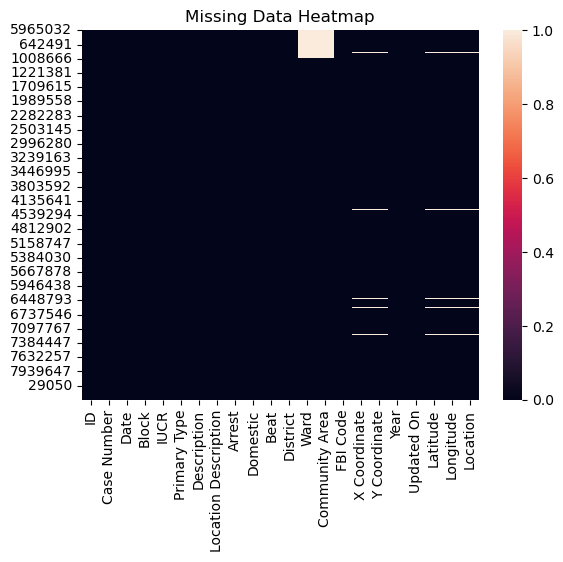

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(missing_values)
plt.title("Missing Data Heatmap")
plt.show()

In [16]:
import numpy as np
import geopandas as gpd

community_areas = gpd.read_file("./data/chicago_community_areas/geo_export_a6df0e5e-f6bd-41de-bed3-2d329795f76a.shp")
#  State Plane Illinois East NAD 1983 projection to match the X,Y coordinates on crime data.
community_areas = community_areas.to_crs('EPSG:3435') 
# community_areas['beat_num'] = community_areas['beat_num'].astype(int)

# Calculate the centroid of community_areas
community_areas['centroid_x'] = community_areas.centroid.x
community_areas['centroid_y'] = community_areas.centroid.y

community_areas.rename({'area_num_1': 'area_id'}, axis=1, inplace=True)
community_areas['area_id'] = community_areas['area_id'].astype(int)

# Convert existing df to geodf
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['X Coordinate'], df['Y Coordinate']))
gdf = gdf.set_crs("EPSG:3435")



In [18]:
# Assign community areas to crime data
df = gpd.sjoin(gdf, community_areas, how="left", predicate='within')[df.columns.tolist() + ['area_id']]

# Fill missing community area values with area_id from the community areas shapefile within which the crime occurred
df['Community Area'] = df['Community Area'].fillna(df['area_id'])
df = df.drop(columns=['area_id'])

In [25]:
df['Location Description'] = df['Location Description'].fillna('Unknown')
df['Ward'] = df['Ward'].fillna(-1)
df['District'] = df['District'].fillna(-1)
df = df.dropna(subset=['X Coordinate', 'Y Coordinate', 'Community Area'])

In [27]:
missing_values = df.isna()
print("Missing Values:\n", missing_values.sum())


Missing Values:
 ID                      0
Case Number             0
Date                    0
Block                   0
IUCR                    0
Primary Type            0
Description             0
Location Description    0
Arrest                  0
Domestic                0
Beat                    0
District                0
Ward                    0
Community Area          0
FBI Code                0
X Coordinate            0
Y Coordinate            0
Year                    0
Updated On              0
Latitude                0
Longitude               0
Location                0
dtype: int64


In [ ]:
cleaned_file_name = "cleaned_Crimes_-_2001_to_Present_20250114.csv"

df.to_csv(base_data_path / cleaned_file_name)